In [2]:
2+2

4

In [1]:
print("Hello")

Hello


In [4]:
import os
os.environ['TAVILY_API_KEY']=os.getenv('TAVILY_API_KEY')
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model=ChatGroq(model="qwen/qwen3-32b")

In [12]:
from langchain_tavily import TavilySearch

taviy_search_tool =  TavilySearch(
  maxResults =  5,
  topic= "general",
)


taviy_search_tool.invoke("What is the current AI news?")

{'query': 'What is the current AI news?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
   'title': 'Latest AI News, Developments, and Breakthroughs | 2026',
   'content': 'Summary: Apple has officially announced that a completely reimagined, AI-powered version of Siri is set to debut in 2026. This fundamental transformation will',
   'score': 0.7045877,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology.',
   'score': 0.6628188,
   'raw_content': None},
  {'url': 'https://www.reuters.com/technology/artificial-intelligence/',
   'title': 'AI News | Latest Headlines and Developments | Reuters',
   'content': 'Explore the latest artificial intelligence news with R

In [10]:
from langchain.tools import tool
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [13]:
from langchain.agents import create_agent

agent = create_agent (model, [taviy_search_tool, calc])


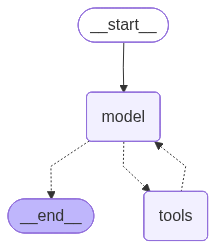

In [14]:
agent

In [15]:
user_input = "What is the current AI news for Antropic and what is the sum of 5+5"
for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news for Antropic and what is the sum of 5+5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8dwtxhp4f)
 Call ID: 8dwtxhp4f
  Args:
    query: current AI news for Antropic
    time_range: week
    topic: news
  calculator (y6wfbsf4y)
 Call ID: y6wfbsf4y
  Args:
    expression: 5+5
================================= Tool Message =================================
Name: calculator

10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1er6f9jds)
 Call ID: 1er6f9jds
  Args:
    query: recent AI developments at Anthropic
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI developments at Anthropic", "follow_up_questions": null, "answer": null, "images": [